<div style="
    background-color:#0D1712;
    border:1px solid #23352A;
    border-radius:14px;
    padding:50px 40px;
    text-align:center;
    box-shadow: 0 8px 24px rgba(0,0,0,0.25);
    font-family: 'Helvetica Neue', Arial, sans-serif;
    margin-bottom: 30px;
">

<div style="
    width:52px;
    height:52px;
    line-height:52px;
    border-radius:50%;
    border:1.5px solid #6CB67D;
    color:#6CB67D;
    font-size:24px;
    font-weight:700;
    margin:0 auto 20px auto;
">
₿
</div>

<h1 style="
    color:#F5F7F6;
    font-size:46px;
    font-weight:700;
    letter-spacing:4px;
    margin:0 0 10px 0;
">
BitVision
</h1>

<p style="
    color:#6CB67D;
    font-size:16px;
    font-weight:400;
    letter-spacing:1px;
    margin:0 0 6px 0;
    text-align:center;
">
An AI-Powered Bitcoin Forecasting & Analytics Platform
</p>

<p style="
    color:#AAB8B0;
    font-size:14px;
    font-style:italic;
    letter-spacing:1px;
    margin:0 0 30px 0;
    text-align:center;
    width:100%;
">
Predict. Visualize. Decide. Master the crypto candles with AI.
</p>

<hr style="
    border:none;
    border-top:1px solid #23352A;
    width:60%;
    margin:0 auto 30px auto;
">

<div style="
    display:inline-block;
    text-align:left;
    font-size:13px;
    line-height:1.9;
">

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Version</span>
<span style="color:#F5F7F6;">v2.0 Intelligence</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Notebook</span>
<span style="color:#F5F7F6;">02_Feature_Engineering.ipynb</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Author</span>
<span style="color:#F5F7F6;">Team BitVision</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px; vertical-align:top;">Tech Stack</span>
<span style="color:#F5F7F6;">Python • Pandas • NumPy • Matplotlib • Seaborn • Plotly • Scikit-learn</span>
</div>

</div>

</div>

# INTRODUCTION
Feature Engineering is one of the most important stages in the machine learning pipeline. It involves creating new and meaningful features from existing data to help machine learning models better understand hidden patterns and relationships within the dataset.

In this notebook, we transform the cleaned Bitcoin dataset into a richer dataset by generating features that capture market trends, momentum, historical behaviour, and price volatility. These engineered features provide additional context that can significantly improve the predictive performance of future machine learning models.

The final output of this notebook will be a feature-engineered dataset that is ready for feature selection and model development in the next stages of the <b>BitVision</b> project.

# OBJECTIVES

The objectives of this notebook are:

- Generate meaningful features from the cleaned Bitcoin dataset.
- Capture market trends and historical price behaviour.
- Create features representing momentum and market volatility.
- Improve the learning capability of future machine learning models.
- Validate all engineered features before model development.
- Prepare the final dataset for Feature Selection and Machine Learning.

# WORKFLOW

The Feature Engineering process followed in this notebook is illustrated below:

1. Import Required Libraries
2. Load Cleaned Dataset
3. Dataset Overview
4. Create Engineered Features
   - Daily Return
   - Lag Features
   - Moving Averages
   - Exponential Moving Averages
   - Rate of Change
   - Rolling Statistics
   - Volatility
   - Price Range
5. Validate Engineered Features
6. Visualize New Features
7. Save Final Feature Engineered Dataset


## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# Plot Settings
plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

## Loading Cleaned Dataset

In [3]:
df = pd.read_csv("bitcoin_data_cleaned.csv")
df

,Date,Close,High,Low,Open,Volume
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8.036550e+06
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7.860650e+06
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,3.305440e+07
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,5.562910e+07
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,4.396280e+07
...,...,...,...,...,...,...
4033,2026-01-16,95525.117188,95801.890625,94259.273438,95554.101562,3.324817e+10
4034,2026-01-17,95099.921875,95598.476562,95005.617188,95525.156250,1.602172e+10
4035,2026-01-18,93634.429688,95491.507812,93588.867188,95101.179688,2.080978e+10
4036,2026-01-19,92553.593750,93660.828125,92089.250000,93655.671875,3.919524e+10


# DATASET OVERVIEW

In [4]:
print("Shape of Dataset :", df.shape)

Shape of Dataset : (4038, 6)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4038 entries, 0 to 4037
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4038 non-null   object 
 1   Close   4038 non-null   float64
 2   High    4038 non-null   float64
 3   Low     4038 non-null   float64
 4   Open    4038 non-null   float64
 5   Volume  4038 non-null   float64
dtypes: float64(5), object(1)
memory usage: 189.4+ KB


In [6]:
df.describe()

,Close,High,Low,Open,Volume
count,4038.000000,4038.000000,4038.000000,4038.000000,4.038000e+03
mean,27867.874589,28404.119305,27258.663350,27847.131604,2.227519e+10
std,32014.185223,32544.332497,31427.022047,32003.678804,2.290265e+10
min,178.102997,211.731003,171.509995,176.897003,7.860650e+06
25%,3688.071167,3827.135925,3641.306946,3682.928345,2.333363e+09
50%,11427.703125,11708.764648,11169.334473,11424.151367,1.789568e+10
75%,43144.678711,43938.967773,42254.566406,43114.065430,3.388749e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


In [7]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## Dataset Summary

The cleaned Bitcoin dataset has been successfully loaded for feature engineering.

Key observations:

- The dataset contains historical Bitcoin market data.
- All missing values have already been handled during Version 1.
- Data types are appropriate for feature creation.
- The dataset is now ready for generating engineered features.
-----

# FEATURE ENGINEERING

Feature engineering is the process of transforming raw data into meaningful input variables that improve the learning capability of machine learning models. Instead of relying only on the original Bitcoin price attributes, additional statistical, trend-based, momentum, and volatility features are generated.

These engineered features capture hidden market patterns and provide richer information, enabling predictive models to learn both short-term and long-term price behaviour more effectively.

# Feature 1: Daily Return

Daily Return represents the percentage change in Bitcoin's closing price from one trading day to the next.

Rather than looking at the absolute price, Daily Return measures how much the price has increased or decreased relative to the previous day's closing price.

This feature helps capture the short-term momentum of the market and is widely used in financial analysis, quantitative trading, and machine learning models for stock and cryptocurrency price prediction.


### Formula

$$
\text{Daily Return} = \frac{\text{Current Close Price} - \text{Previous Close Price}}{\text{Previous Close Price}}
$$

The calculated value represents the percentage change in Bitcoin's closing price compared to the previous trading day.

## Creating the Daily Return Feature

In [8]:
df["Daily_Return"] = df["Close"].pct_change()

df[["Date","Close","Daily_Return"]].head(10)

,Date,Close,Daily_Return
0,2015-01-01,314.248993,NaN
1,2015-01-02,315.032013,0.002492
2,2015-01-03,281.082001,-0.107767
3,2015-01-04,264.195007,-0.060079
4,2015-01-05,274.473999,0.038907
5,2015-01-06,286.188995,0.042682
6,2015-01-07,294.337006,0.028471
7,2015-01-08,283.348999,-0.037331
8,2015-01-09,290.407990,0.024913
9,2015-01-10,274.795990,-0.053759


### Observation

The Daily Return feature captures day-to-day percentage price movements. Since the first observation has no previous trading day for comparison, its value is missing (NaN), which is expected.

## Validation

In [9]:
print("Missing Values in Daily Return :", df["Daily_Return"].isnull().sum())

Missing Values in Daily Return : 1


### Why is there one missing value?

The first observation does not have a previous trading day for comparison.

Since Daily Return is calculated relative to the previous closing price, the first row naturally contains a missing value (NaN). This is expected behaviour and does not indicate a data quality issue.

## Visualization

### Distribution of Daily Returns

The distribution of Daily Return helps us understand how Bitcoin's daily price changes are spread over time. It allows us to identify whether daily returns are concentrated around small changes or whether large gains and losses occur frequently.

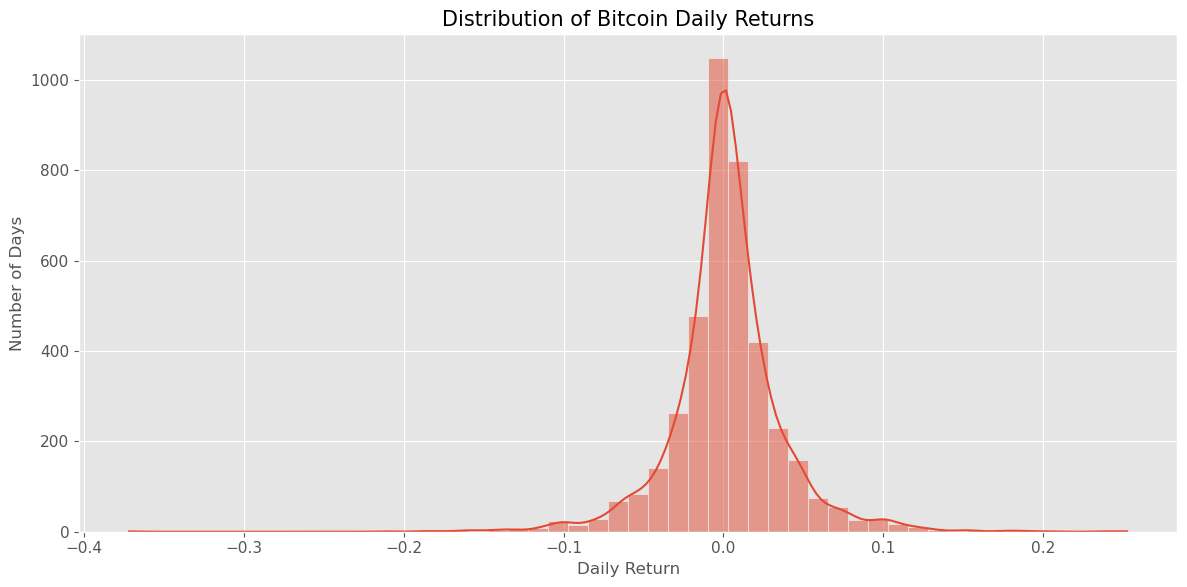

In [10]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["Daily_Return"],
    bins=50,
    kde=True
)

plt.title("Distribution of Bitcoin Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Number of Days")

plt.tight_layout()
plt.show()

## Time Series of Daily Returns

A time-series plot of Daily Return illustrates how Bitcoin's percentage price change fluctuates over time. It helps identify periods of high volatility, stable market conditions, and sudden price movements.

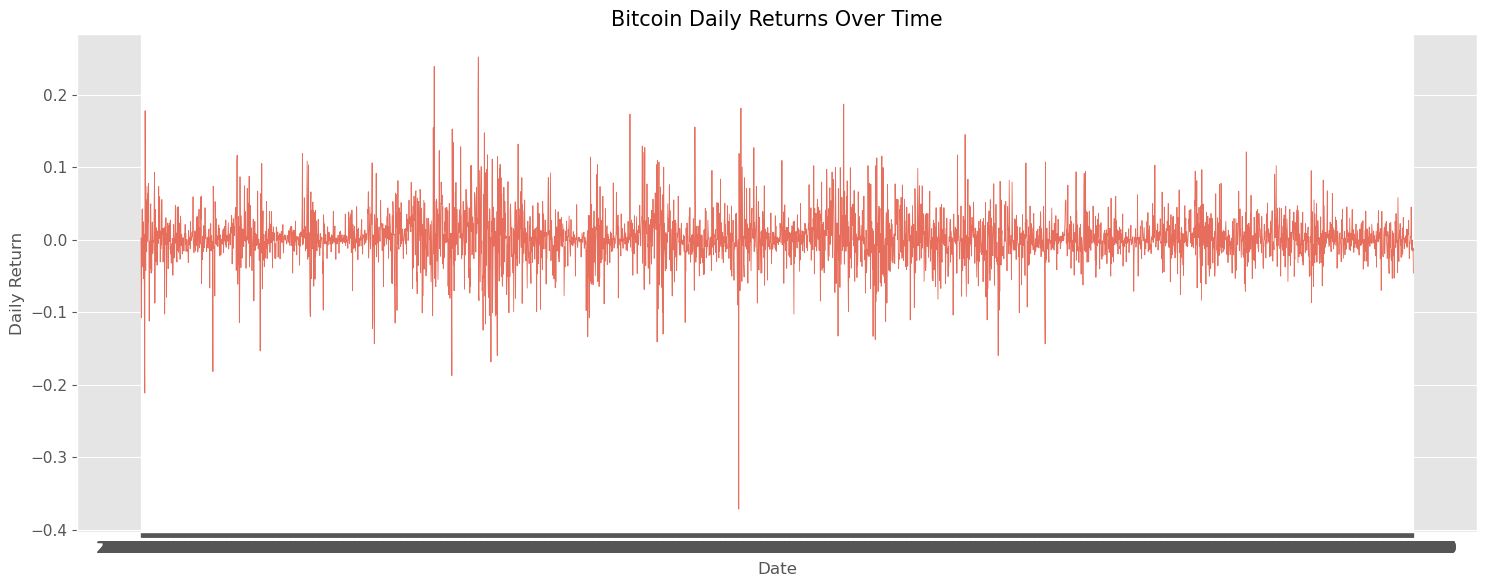

In [11]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Daily_Return"],
    linewidth=0.6,
    alpha=0.8
)

plt.title("Bitcoin Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.tight_layout()
plt.show()

## Observation

- Most daily returns are concentrated around zero, indicating that Bitcoin experiences relatively small price changes on the majority of trading days.
- The distribution contains a few extreme positive and negative returns, representing periods of unusually high market volatility.
- The time-series plot shows that volatility is not constant over time, with certain periods experiencing significantly larger price fluctuations than others.

## Business Insight

Although most daily price movements are modest, occasional periods of extreme volatility can lead to substantial gains or losses within a short duration. These fluctuations are important for investors when assessing market risk.


## Machine Learning Insight

Daily Return captures short-term momentum more effectively than raw closing prices. By learning patterns in percentage changes rather than absolute prices, models can better generalise across different price levels.


# Feature 2: Lag Features

Lag Features are values from previous time periods that are used as input features for predicting future values.

In time-series forecasting, the current value often depends on historical observations rather than existing independently. By shifting previous closing prices into new columns, we provide the model with historical context that can help identify temporal patterns.

For this project, we create lag features representing the previous day, the previous three days, the previous week, and the previous month.


## Importance of Lag Features

Time-series data is sequential, meaning that past observations often influence future outcomes.

Lag Features allow the model to learn short-term and long-term dependencies in Bitcoin prices. Instead of relying only on today's information, the model gains access to historical price behaviour across multiple time horizons.

These features are among the most important predictors in time-series forecasting because financial markets frequently exhibit temporal dependencies.

## Formula

For a lag of **k** days:

**Lagₖ = Closing Price from k days ago**

where:

- **Lag₁** = Previous day's closing price
- **Lag₃** = Closing price from 3 days ago
- **Lag₇** = Closing price from 7 days ago
- **Lag₃₀** = Closing price from 30 days ago

## Creating Lag Features

In [12]:
df["Lag_1"] = df["Close"].shift(1)
df["Lag_3"] = df["Close"].shift(3)
df["Lag_7"] = df["Close"].shift(7)
df["Lag_30"] = df["Close"].shift(30)

In [13]:
df[
    [
        "Date",
        "Close",
        "Lag_1",
        "Lag_3",
        "Lag_7",
        "Lag_30"
    ]
].head(35)

,Date,Close,Lag_1,Lag_3,Lag_7,Lag_30
0,2015-01-01,314.248993,NaN,NaN,NaN,NaN
1,2015-01-02,315.032013,314.248993,NaN,NaN,NaN
2,2015-01-03,281.082001,315.032013,NaN,NaN,NaN
3,2015-01-04,264.195007,281.082001,314.248993,NaN,NaN
4,2015-01-05,274.473999,264.195007,315.032013,NaN,NaN
5,2015-01-06,286.188995,274.473999,281.082001,NaN,NaN
6,2015-01-07,294.337006,286.188995,264.195007,NaN,NaN
7,2015-01-08,283.348999,294.337006,274.473999,314.248993,NaN
8,2015-01-09,290.407990,283.348999,286.188995,315.032013,NaN
9,2015-01-10,274.795990,290.407990,294.337006,281.082001,NaN


## Validation

In [14]:
print("Missing Values in Lag Features:")

print("Lag_1 :", df["Lag_1"].isnull().sum())
print("Lag_3 :", df["Lag_3"].isnull().sum())
print("Lag_7 :", df["Lag_7"].isnull().sum())
print("Lag_30:", df["Lag_30"].isnull().sum())

Missing Values in Lag Features:
Lag_1 : 1
Lag_3 : 3
Lag_7 : 7
Lag_30: 30


### Why do Lag Features contain missing values?

Lag Features are created by shifting historical closing prices downward.

As a result, the first few rows do not have enough previous observations to populate the lag values.

For example:

- Lag₁ requires one previous day's closing price.
- Lag₃ requires three previous observations.
- Lag₇ requires seven previous observations.
- Lag₃₀ requires thirty previous observations.

These missing values are expected and will be handled during data preprocessing before training the machine learning models.

## Visualization

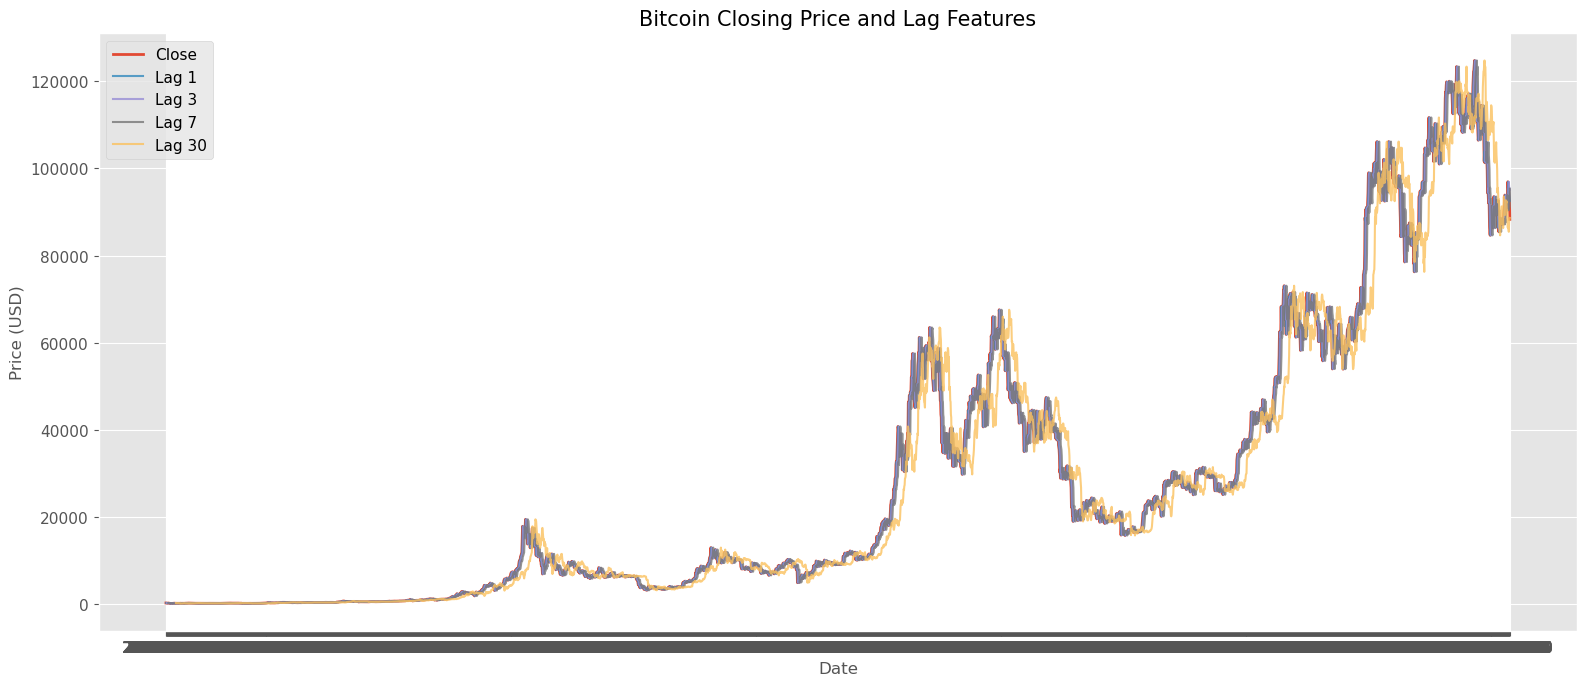

In [15]:
plt.figure(figsize=(16,7))

plt.plot(df["Date"], df["Close"], label="Close", linewidth=2)

plt.plot(df["Date"], df["Lag_1"], label="Lag 1", alpha=0.8)

plt.plot(df["Date"], df["Lag_3"], label="Lag 3", alpha=0.8)

plt.plot(df["Date"], df["Lag_7"], label="Lag 7", alpha=0.8)

plt.plot(df["Date"], df["Lag_30"], label="Lag 30", alpha=0.8)

plt.title("Bitcoin Closing Price and Lag Features")

plt.xlabel("Date")

plt.ylabel("Price (USD)")

plt.legend()

plt.tight_layout()

plt.show()

## Observation

- All lag features follow the overall trend of the closing price but are shifted backward in time.
- Short-term lag features such as Lag₁ closely resemble the current closing price, while longer-term lag features exhibit greater temporal separation.
- As the lag interval increases, the delay between the current and historical prices becomes more pronounced.
- The initial missing values are expected because sufficient historical observations are required before each lag feature can be generated.

## Business Insight

Lag Features enable analysts to compare current market conditions with recent historical behaviour across multiple time horizons, supporting trend analysis and informed decision-making.


## Machine Learning Insight

Lag Features allow models to learn temporal dependencies in Bitcoin prices. Financial markets frequently exhibit such dependencies, making lag-based predictors among the most informative in time-series forecasting.


# Feature 3: Moving Average (MA)

A Moving Average (MA) is a statistical technique that calculates the average closing price over a fixed number of previous trading days.

It smooths short-term price fluctuations, making it easier to identify the underlying market trend by reducing daily price noise.


## Importance of Moving Average

Bitcoin prices are highly volatile and often experience significant day-to-day fluctuations. These short-term movements can make it difficult to identify the actual market trend.

Moving Averages reduce this noise by averaging historical prices over a fixed period, enabling analysts and machine learning models to better understand the overall direction of the market.


## Formula

For an n-day Moving Average:

**Moving Average = (P₁ + P₂ + ... + Pₙ) / n**

where **P** represents the closing price and **n** is the window size.

## Creating Moving Average Features

In [16]:
df["MA_7"] = df["Close"].rolling(window=7).mean()
df["MA_30"] = df["Close"].rolling(window=30).mean()

## Preview

In [17]:
df[
    [
        "Date",
        "Close",
        "MA_7",
        "MA_30"
    ]
].head(35)

,Date,Close,MA_7,MA_30
0,2015-01-01,314.248993,NaN,NaN
1,2015-01-02,315.032013,NaN,NaN
2,2015-01-03,281.082001,NaN,NaN
3,2015-01-04,264.195007,NaN,NaN
4,2015-01-05,274.473999,NaN,NaN
5,2015-01-06,286.188995,NaN,NaN
6,2015-01-07,294.337006,289.936859,NaN
7,2015-01-08,283.348999,285.522574,NaN
8,2015-01-09,290.407990,282.004857,NaN
9,2015-01-10,274.795990,281.106855,NaN


## Validation

In [18]:
print("Missing Values in Moving Average Features:")
print(df[["MA_7", "MA_30"]].isnull().sum())

Missing Values in Moving Average Features:
MA_7      6
MA_30    29
dtype: int64


### Why do Moving Average features contain missing values?

A Moving Average can only be calculated when sufficient historical observations are available.

For a 7-day Moving Average, the first six rows do not contain enough previous closing prices. Similarly, a 30-day Moving Average requires thirty observations, resulting in missing values for the first twenty-nine rows.

These missing values are expected and will be handled during data preprocessing before model training.

In [19]:
print("Summary Statistics:")
print(df[["MA_7", "MA_30"]].describe())

Summary Statistics:
                MA_7          MA_30
count    4032.000000    4009.000000
mean    27840.421560   27735.392954
std     31959.361573   31759.071456
min       204.545569     225.519800
25%      3767.270691    3772.640226
50%     11443.215193   11140.771452
75%     43010.741908   43030.095964
max    122781.400670  117506.825000


## Visualization

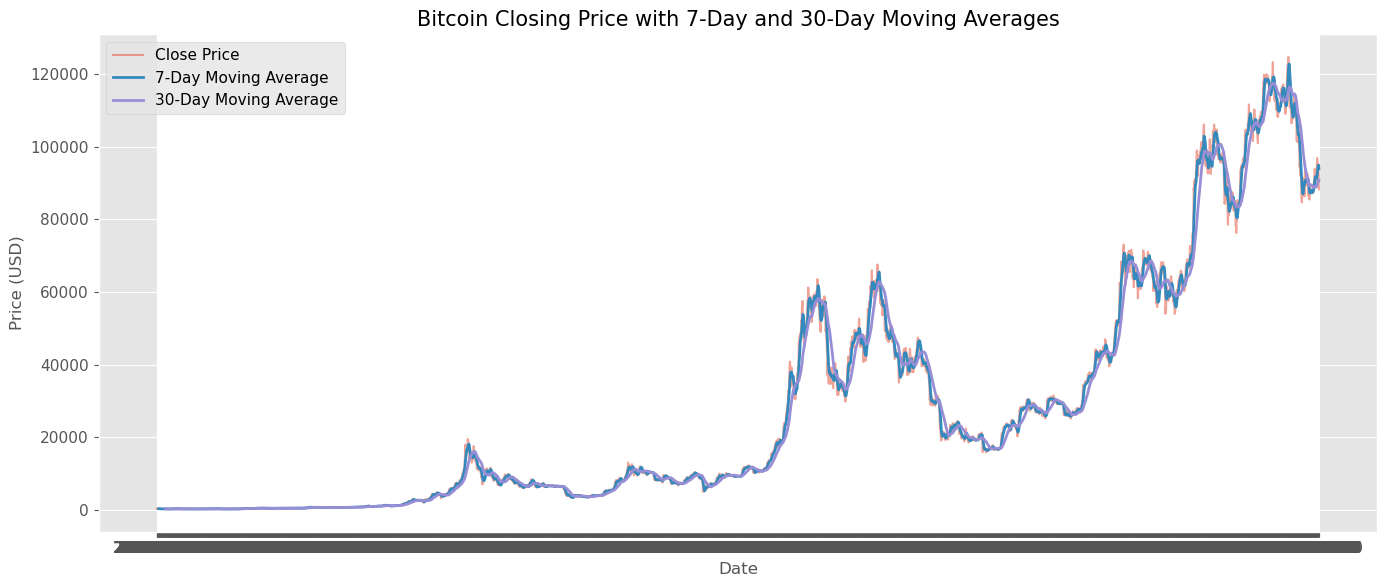

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close Price", alpha=0.5)
plt.plot(df["Date"], df["MA_7"], label="7-Day Moving Average", linewidth=2)
plt.plot(df["Date"], df["MA_30"], label="30-Day Moving Average", linewidth=2)

plt.title("Bitcoin Closing Price with 7-Day and 30-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.tight_layout()
plt.show()

## Observation

- The 7-day Moving Average follows the closing price more closely and responds quickly to short-term market movements.
- The 30-day Moving Average is smoother and captures the long-term market trend.
- Both Moving Averages reduce short-term price fluctuations, making the underlying trend easier to interpret.
- The initial missing values are expected because sufficient historical observations are required to compute each Moving Average.

## Business Insight

Moving Averages are widely used in financial markets to identify trend direction. Short-term averages help monitor recent market behaviour, while long-term averages provide a broader view of overall market trends.


## Machine Learning Insight

Including both short-term and long-term Moving Averages enables models to capture market behaviour at different time horizons, separating transient noise from sustained trends.


# Feature 4: Exponential Moving Average (EMA)

An Exponential Moving Average (EMA) is a trend-based indicator that gives greater importance to recent closing prices. Compared with a Simple Moving Average (SMA), EMA responds more quickly to recent market movements while still smoothing short-term price fluctuations.


## Formula

For an n-day Exponential Moving Average:

**EMA? = ?P? + (1 ? ?)EMA???**

where:

- **P?** = Current closing price
- **EMA???** = Previous Exponential Moving Average value
- **?** = 2 / (n + 1)


## Creating Exponential Moving Average Features


In [21]:
df["EMA_7"] = df["Close"].ewm(span=7, adjust=False).mean()
df["EMA_30"] = df["Close"].ewm(span=30, adjust=False).mean()


## Preview


In [22]:
df[ [ "Date", "Close", "EMA_7", "EMA_30" ] ].head(35)


,Date,Close,EMA_7,EMA_30
0,2015-01-01,314.248993,314.248993,314.248993
1,2015-01-02,315.032013,314.444748,314.299510
2,2015-01-03,281.082001,306.104061,312.156445
3,2015-01-04,264.195007,295.626798,309.062159
4,2015-01-05,274.473999,290.338598,306.830665
5,2015-01-06,286.188995,289.301197,305.498944
6,2015-01-07,294.337006,290.560149,304.778819
7,2015-01-08,283.348999,288.757362,303.396250
8,2015-01-09,290.407990,289.170019,302.558298
9,2015-01-10,274.795990,285.576512,300.767181


## Validation


In [23]:
print("Missing Values in Exponential Moving Average Features:")
print(df[["EMA_7", "EMA_30"]].isnull().sum())


Missing Values in Exponential Moving Average Features:
EMA_7     0
EMA_30    0
dtype: int64


## Visualization

### Simple Moving Average vs Exponential Moving Average

The comparison below shows how SMA and EMA capture Bitcoin price trends. EMA places greater weight on recent prices, while SMA gives equal weight to all observations within the selected window.


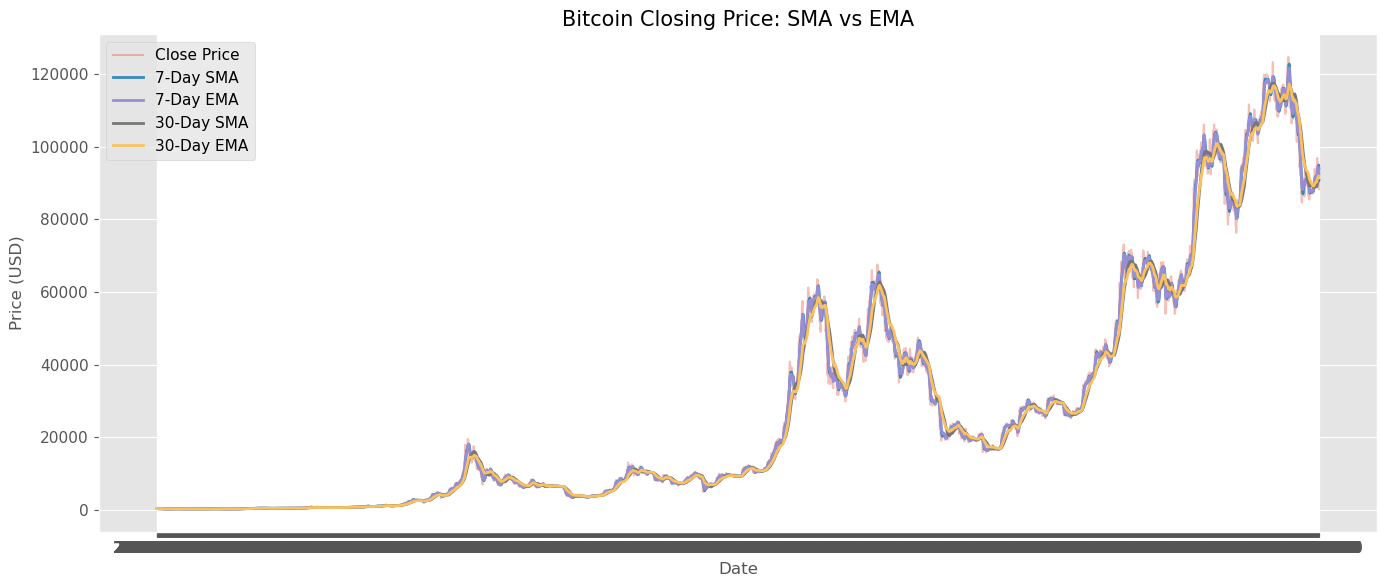

In [24]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"], label="Close Price", alpha=0.35)
plt.plot(df["Date"], df["MA_7"], label="7-Day SMA", linewidth=2)
plt.plot(df["Date"], df["EMA_7"], label="7-Day EMA", linewidth=2)
plt.plot(df["Date"], df["MA_30"], label="30-Day SMA", linewidth=2)
plt.plot(df["Date"], df["EMA_30"], label="30-Day EMA", linewidth=2)
plt.title("Bitcoin Closing Price: SMA vs EMA")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()


## Observation

- EMA features follow the overall price trend while responding more quickly to recent market changes than Moving Average features.
- The 7-day EMA reacts faster to short-term movements, whereas the 30-day EMA provides a smoother view of the longer-term trend.
- Comparing SMA and EMA highlights the additional responsiveness of exponential weighting during periods of changing Bitcoin prices.


# Feature 5: Rate of Change (ROC)

Rate of Change (ROC) measures the percentage change in Bitcoin's closing price over a selected number of trading days. It captures the strength and direction of price momentum across short-term and longer-term time horizons.


## Formula

For an n-day Rate of Change:

**ROC? = [(Current Close Price ? Close Price? days ago) / Close Price? days ago]**

The calculated value represents the percentage change in closing price over the selected period.


## Creating Rate of Change Features


In [25]:
df["ROC_7"] = df["Close"].pct_change(periods=7)
df["ROC_30"] = df["Close"].pct_change(periods=30)


## Preview


In [26]:
df[ [ "Date", "Close", "ROC_7", "ROC_30" ] ].head(35)


,Date,Close,ROC_7,ROC_30
0,2015-01-01,314.248993,NaN,NaN
1,2015-01-02,315.032013,NaN,NaN
2,2015-01-03,281.082001,NaN,NaN
3,2015-01-04,264.195007,NaN,NaN
4,2015-01-05,274.473999,NaN,NaN
5,2015-01-06,286.188995,NaN,NaN
6,2015-01-07,294.337006,NaN,NaN
7,2015-01-08,283.348999,-0.098330,NaN
8,2015-01-09,290.407990,-0.078164,NaN
9,2015-01-10,274.795990,-0.022364,NaN


## Validation


In [27]:
print("Missing Values in Rate of Change Features:")
print(df[["ROC_7", "ROC_30"]].isnull().sum())


Missing Values in Rate of Change Features:
ROC_7      7
ROC_30    30
dtype: int64


## Observation

- ROC values show the percentage change in Bitcoin price over 7-day and 30-day periods.
- Positive ROC values indicate upward price momentum, while negative values indicate downward momentum.
- ROC_7 responds to recent market changes, whereas ROC_30 captures momentum over a broader time horizon.


# Feature 6: Rolling Standard Deviation

Rolling Standard Deviation is a statistical measure that calculates the standard deviation of observations within a moving window.

Unlike a single standard deviation computed for the entire dataset, Rolling Standard Deviation continuously updates as the window moves through the data. It measures how much the closing prices vary around their rolling mean over time.

A higher Rolling Standard Deviation indicates greater price fluctuations, while a lower value indicates more stable price movements.


## Importance of Rolling Standard Deviation

Financial markets often alternate between periods of stability and high volatility.

Rolling Standard Deviation helps identify these changing market conditions by measuring the variability of prices within a fixed window. It is widely used in financial analysis and serves as the basis for calculating volatility-related indicators.

## Formula

For a rolling window containing **n** observations:

**Rolling Standard Deviation = ?[(?(x? ? x?)?) / (n ? 1)]**

where:

- **x?** = Closing Price
- **x?** = Average closing price within the rolling window
- **n** = Window Size


## Creating Rolling Standard Deviation Feature

In [28]:
df["Rolling_STD_7"] = df["Close"].rolling(window=7).std()

In [29]:
df[
    [
        "Date",
        "Close",
        "Rolling_STD_7"
    ]
].head(15)

,Date,Close,Rolling_STD_7
0,2015-01-01,314.248993,NaN
1,2015-01-02,315.032013,NaN
2,2015-01-03,281.082001,NaN
3,2015-01-04,264.195007,NaN
4,2015-01-05,274.473999,NaN
5,2015-01-06,286.188995,NaN
6,2015-01-07,294.337006,19.297694
7,2015-01-08,283.348999,16.074434
8,2015-01-09,290.407990,10.138742
9,2015-01-10,274.795990,10.505838


## Validation

In [30]:
print("Missing Values in Rolling_STD_7:")
print(df["Rolling_STD_7"].isnull().sum())

Missing Values in Rolling_STD_7:
6


### Why does Rolling Standard Deviation contain missing values?

A 7-day Rolling Standard Deviation requires seven consecutive observations to calculate the variability of prices within the window.

Therefore, the first six rows do not contain sufficient historical data, resulting in missing values. These missing values are expected and will be handled during data preprocessing before model training.

In [31]:
print("Summary Statistics:")
print(df["Rolling_STD_7"].describe())

Summary Statistics:
count    4032.000000
mean      795.450569
std       981.063075
min         1.106973
25%        80.839219
50%       378.305178
75%      1209.877020
max      6446.206716
Name: Rolling_STD_7, dtype: float64


## Visualization

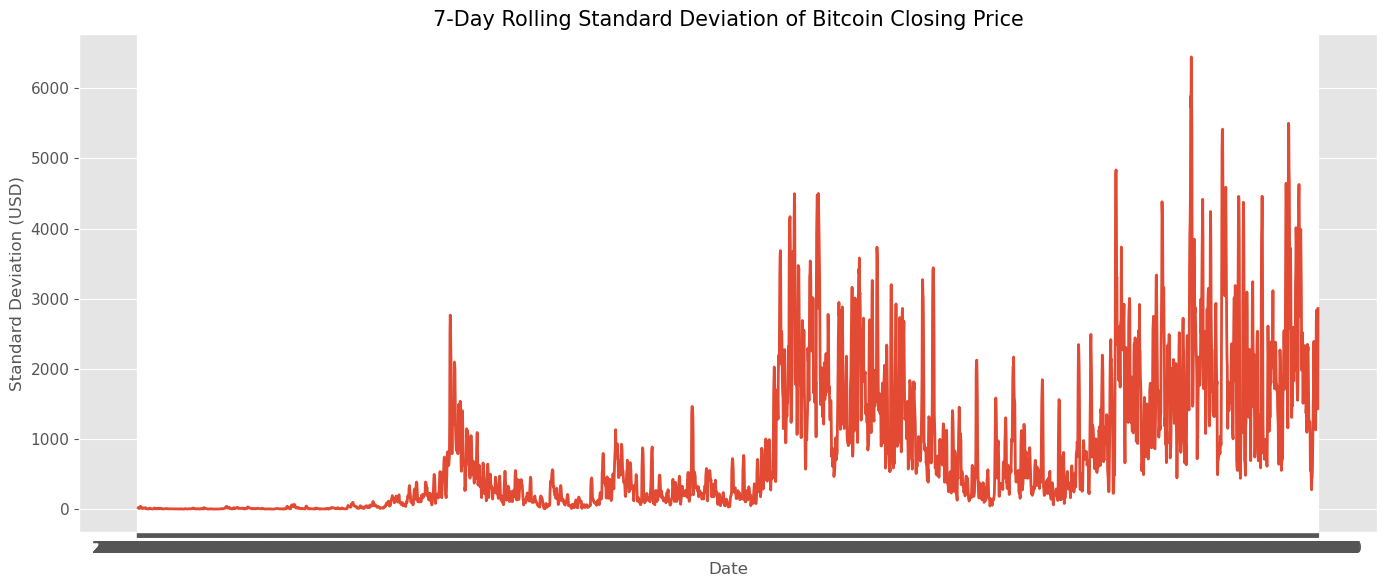

In [32]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Rolling_STD_7"],
    linewidth=2
)

plt.title("7-Day Rolling Standard Deviation of Bitcoin Closing Price")
plt.xlabel("Date")
plt.ylabel("Standard Deviation (USD)")

plt.tight_layout()
plt.show()

## Observation

- The Rolling Standard Deviation changes continuously as new price data becomes available.
- Higher values indicate periods of increased market volatility, while lower values represent relatively stable market conditions.
- Fluctuations in Rolling Standard Deviation highlight changing levels of market uncertainty over time.
- The initial missing values occur because a complete 7-day window is required for the calculation.

## Business Insight

Identifying periods of elevated price variability supports risk assessment, portfolio management, and informed investment decisions.


## Machine Learning Insight

Rolling Standard Deviation complements trend-based features by capturing changes in market dispersion, enabling models to distinguish between stable and volatile market regimes.


# Feature 7: Historical Volatility

Historical Volatility (HV) is a statistical measure that quantifies how much an asset's returns have fluctuated over a specific period in the past.

Unlike Rolling Standard Deviation, which measures the variability of prices, Historical Volatility measures the variability of returns. It helps estimate the level of market uncertainty based on historical price movements.


## Importance of Historical Volatility

Bitcoin is known for experiencing periods of both high and low volatility.

Historical Volatility helps quantify these changing market conditions by measuring how widely daily returns fluctuate over time. It is widely used in financial analysis, risk management, portfolio allocation, and trading strategies.

## Formula

Historical Volatility is calculated using the rolling standard deviation of daily returns and annualized as follows:

**Historical Volatility = Rolling Standard Deviation of Daily Returns × √365**

where:

- Daily Returns = Percentage change in closing price
- 365 represents the approximate number of trading days in cryptocurrency markets, which operate continuously throughout the year.

## Creating Historical Volatility Features


In [33]:
df["Historical_Volatility_7"] = (
    df["Daily_Return"]
    .rolling(window=7)
    .std() * np.sqrt(365)
)

df["Historical_Volatility_30"] = (
    df["Daily_Return"]
    .rolling(window=30)
    .std() * np.sqrt(365)
)


In [34]:
df[ [ "Date", "Daily_Return", "Historical_Volatility_7", "Historical_Volatility_30" ] ].head(35)


,Date,Daily_Return,Historical_Volatility_7,Historical_Volatility_30
0,2015-01-01,NaN,NaN,NaN
1,2015-01-02,0.002492,NaN,NaN
2,2015-01-03,-0.107767,NaN,NaN
3,2015-01-04,-0.060079,NaN,NaN
4,2015-01-05,0.038907,NaN,NaN
5,2015-01-06,0.042682,NaN,NaN
6,2015-01-07,0.028471,NaN,NaN
7,2015-01-08,-0.037331,1.090361,NaN
8,2015-01-09,0.024913,1.121603,NaN
9,2015-01-10,-0.053759,0.876274,NaN


## Validation

In [35]:
print("Missing Values in Historical Volatility Features:")
print(df[["Historical_Volatility_7", "Historical_Volatility_30"]].isnull().sum())


Missing Values in Historical Volatility Features:
Historical_Volatility_7      7
Historical_Volatility_30    30
dtype: int64


### Why do Historical Volatility features contain missing values?

Historical Volatility is calculated using the rolling standard deviation of daily returns. Since the first Daily Return is unavailable and complete rolling windows are required, the initial rows contain missing values. Historical_Volatility_7 requires seven daily returns, while Historical_Volatility_30 requires thirty daily returns. These missing values are expected and represent the period before sufficient historical data is available.


In [36]:
print("Summary Statistics:")
print(df[["Historical_Volatility_7", "Historical_Volatility_30"]].describe())


Summary Statistics:
       Historical_Volatility_7  Historical_Volatility_30
count              4031.000000               4008.000000
mean                  0.565739                  0.605429
std                   0.360155                  0.277420
min                   0.038175                  0.135548
25%                   0.317626                  0.411958
50%                   0.477935                  0.549754
75%                   0.722204                  0.740780
max                   3.033791                  1.744867


## Visualization

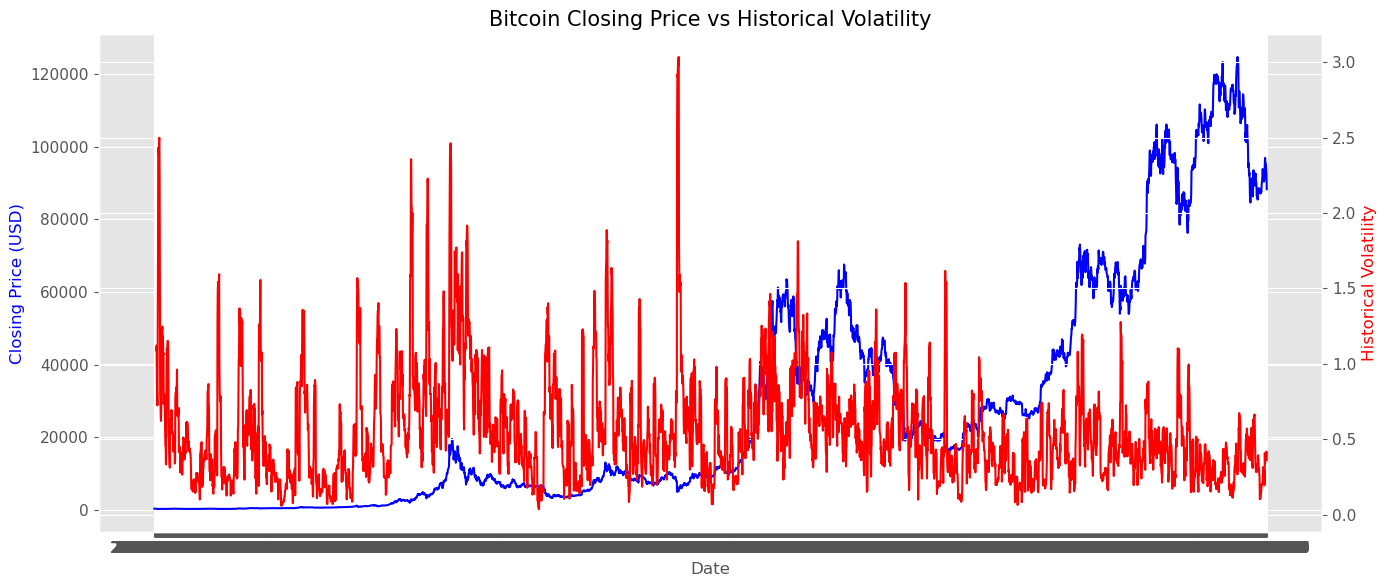

In [37]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Left Axis (Price)
ax1.plot(df["Date"], df["Close"], label="Closing Price", color="blue")
ax1.set_xlabel("Date")
ax1.set_ylabel("Closing Price (USD)", color="blue")

# Right Axis (Volatility)
ax2 = ax1.twinx()
ax2.plot(
    df["Date"],
    df["Historical_Volatility_7"],
    label="Historical Volatility",
    color="red"
)
ax2.set_ylabel("Historical Volatility", color="red")

plt.title("Bitcoin Closing Price vs Historical Volatility")

plt.tight_layout()
plt.show()

## Observation

- Historical Volatility changes continuously over time as market conditions evolve.
- Historical_Volatility_7 responds more quickly to recent changes in daily return fluctuations, while Historical_Volatility_30 provides a broader view of market risk.
- Higher values indicate periods of increased market uncertainty and larger price swings, whereas lower values represent relatively stable market conditions.


## Business Insight

During periods of high volatility, investors may adopt more cautious trading strategies, while lower volatility often indicates more stable conditions suitable for different risk profiles.


## Machine Learning Insight

Combining volatility-based features with trend-based features enables models to capture both price direction and market uncertainty, providing a more complete picture of market dynamics.


# Feature 8: Price Range

Price Range is the difference between the highest and lowest price of an asset during a trading period.

It measures how much the price moved within a single day, regardless of whether the market ultimately closed higher or lower.


## Importance of Price Range

Closing price alone does not reveal how much the market fluctuated during the day.

Price Range captures the extent of intraday movement and provides additional information about market activity, trading intensity, and short-term uncertainty.

## Formula

**Price Range = High − Low**

where:

- **High** = Highest price during the day
- **Low** = Lowest price during the day

## Creating Price Range Feature

In [38]:
df["Price_Range"] = df["High"] - df["Low"]

In [39]:
df[
    [
        "Date",
        "High",
        "Low",
        "Price_Range"
    ]
].head()

,Date,High,Low,Price_Range
0,2015-01-01,320.434998,314.002991,6.432007
1,2015-01-02,315.838989,313.565002,2.273987
2,2015-01-03,315.149994,281.082001,34.067993
3,2015-01-04,287.230011,257.612000,29.618011
4,2015-01-05,278.341003,265.084015,13.256989


## Validation

In [40]:
print("Missing Values in Price_Range:")
print(df["Price_Range"].isnull().sum())

Missing Values in Price_Range:
0


### Why are there no missing values?

Price Range is calculated directly from the existing **High** and **Low** price columns.

Since both columns are already available for every trading day, the engineered feature does not introduce any additional missing values.

In [41]:
print("Summary Statistics:")
print(df["Price_Range"].describe())

Summary Statistics:
count     4038.000000
mean      1145.455955
std       1544.402367
min          1.028000
25%        100.019836
50%        476.260254
75%       1684.716309
max      17927.250000
Name: Price_Range, dtype: float64


## Visualization

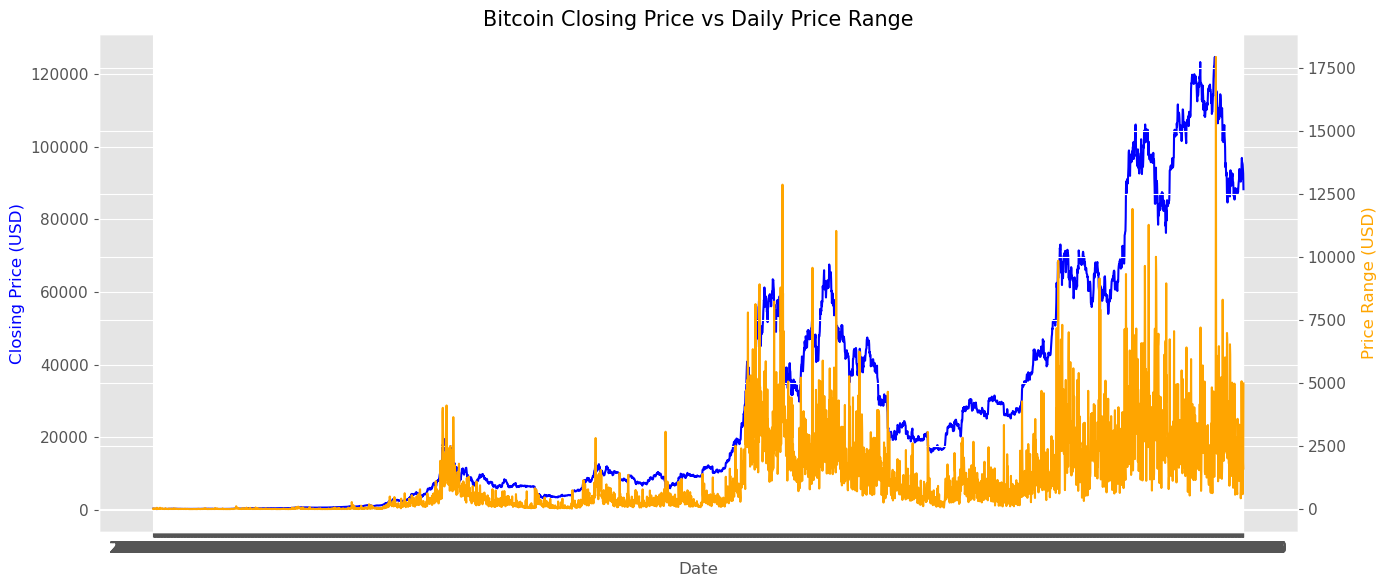

In [42]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Closing Price
ax1.plot(
    df["Date"],
    df["Close"],
    label="Closing Price",
    color="blue"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Closing Price (USD)", color="blue")

# Price Range
ax2 = ax1.twinx()

ax2.plot(
    df["Date"],
    df["Price_Range"],
    label="Price Range",
    color="orange"
)

ax2.set_ylabel("Price Range (USD)", color="orange")

plt.title("Bitcoin Closing Price vs Daily Price Range")

plt.tight_layout()

plt.show()

Price Range measures the magnitude of movement, while Historical Volatility measures the consistency of return fluctuations over multiple days. Together, these features provide complementary information about market behaviour.

## Observation

- Price Range varies considerably over time, indicating that intraday market activity is not constant.
- Larger Price Range values correspond to days with greater price movement between the daily high and low.
- Smaller Price Range values indicate relatively stable trading sessions.
- Comparing Price Range with the Closing Price shows that high-priced periods are not always the most volatile, highlighting that market movement depends on more than just the asset's price level.

## Business Insight

A larger Price Range often reflects increased trading activity or stronger market reactions, while a smaller range indicates relatively stable trading sessions.


## Machine Learning Insight

Price Range provides information about intraday market dynamics that cannot be captured by closing prices alone, complementing the daily return and volatility features.


# Feature 9: Feature Correlation

Feature correlation measures the strength and direction of the linear relationship between numerical variables.

It helps us understand how strongly different features are related to one another. Correlation values range from **-1 to +1**, where:

- **+1** indicates a perfect positive correlation.
- **0** indicates no linear relationship.
- **-1** indicates a perfect negative correlation.

By visualising these relationships using a correlation heatmap, we can better understand the interactions among the engineered features.


## Importance of Feature Correlation

After engineering new features, it is essential to evaluate how they relate to each other.

Correlation analysis helps us:

- Understand relationships between engineered features.
- Detect highly correlated features.
- Identify redundant information.
- Verify that the engineered features capture different aspects of market behaviour before model training.

## Creating the Correlation Matrix

In [43]:
correlation_columns = [
    "Close",
    "Daily_Return",
    "Lag_1",
    "Lag_3",
    "Lag_7",
    "Lag_30",
    "MA_7",
    "MA_30",
    "EMA_7",
    "EMA_30",
    "ROC_7",
    "ROC_30",
    "Rolling_STD_7",
    "Historical_Volatility_7",
    "Historical_Volatility_30",
    "Price_Range"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix


,Close,Daily_Return,Lag_1,Lag_3,Lag_7,Lag_30,MA_7,MA_30,EMA_7,EMA_30,ROC_7,ROC_30,Rolling_STD_7,Historical_Volatility_7,Historical_Volatility_30,Price_Range
Close,1.000000,-0.008094,0.999388,0.998259,0.995959,0.981806,0.998923,0.994442,0.999256,0.995746,-0.021050,-0.041643,0.740762,-0.142609,-0.217813,0.724405
Daily_Return,-0.008094,1.000000,-0.030651,-0.030920,-0.031213,-0.035360,-0.027883,-0.032625,-0.024857,-0.029857,0.389834,0.183948,-0.011111,0.011777,0.015663,-0.035132
Lag_1,0.999388,-0.030651,1.000000,0.998827,0.996527,0.982523,0.999335,0.995002,0.999539,0.996277,-0.029620,-0.045831,0.740447,-0.142806,-0.217974,0.726069
Lag_3,0.998259,-0.030920,0.998827,1.000000,0.997692,0.983998,0.999660,0.995987,0.999519,0.997128,-0.046248,-0.054189,0.740067,-0.142309,-0.217992,0.728619
Lag_7,0.995959,-0.031213,0.996527,0.997692,1.000000,0.986550,0.998345,0.997467,0.998212,0.998113,-0.079352,-0.070286,0.738769,-0.139944,-0.217391,0.730328
Lag_30,0.981806,-0.035360,0.982523,0.983998,0.986550,1.000000,0.984605,0.993754,0.984846,0.993023,-0.087612,-0.161792,0.727346,-0.130119,-0.212421,0.715120
MA_7,0.998923,-0.027883,0.999335,0.999660,0.998345,0.984605,1.000000,0.996570,0.999934,0.997666,-0.046136,-0.054105,0.740546,-0.142112,-0.218010,0.728457
MA_30,0.994442,-0.032625,0.995002,0.995987,0.997467,0.993754,0.996570,1.000000,0.996737,0.999755,-0.076287,-0.100593,0.735878,-0.131038,-0.216327,0.725796
EMA_7,0.999256,-0.024857,0.999539,0.999519,0.998212,0.984846,0.999934,0.996737,1.000000,0.997790,-0.042876,-0.054025,0.740706,-0.141884,-0.217968,0.728123
EMA_30,0.995746,-0.029857,0.996277,0.997128,0.998113,0.993023,0.997666,0.999755,0.997790,1.000000,-0.068194,-0.093480,0.737970,-0.139580,-0.216992,0.727234


## Validation

In [44]:
print("Shape of Correlation Matrix:")
print(correlation_matrix.shape)

print("\nMissing Values:")
print(correlation_matrix.isnull().sum().sum())

Shape of Correlation Matrix:
(16, 16)

Missing Values:
0


### Why are there no missing values?

The correlation matrix is computed using numerical features after excluding missing observations required for each pairwise correlation calculation. As a result, the correlation matrix itself contains valid correlation coefficients without missing values.

## Visualization

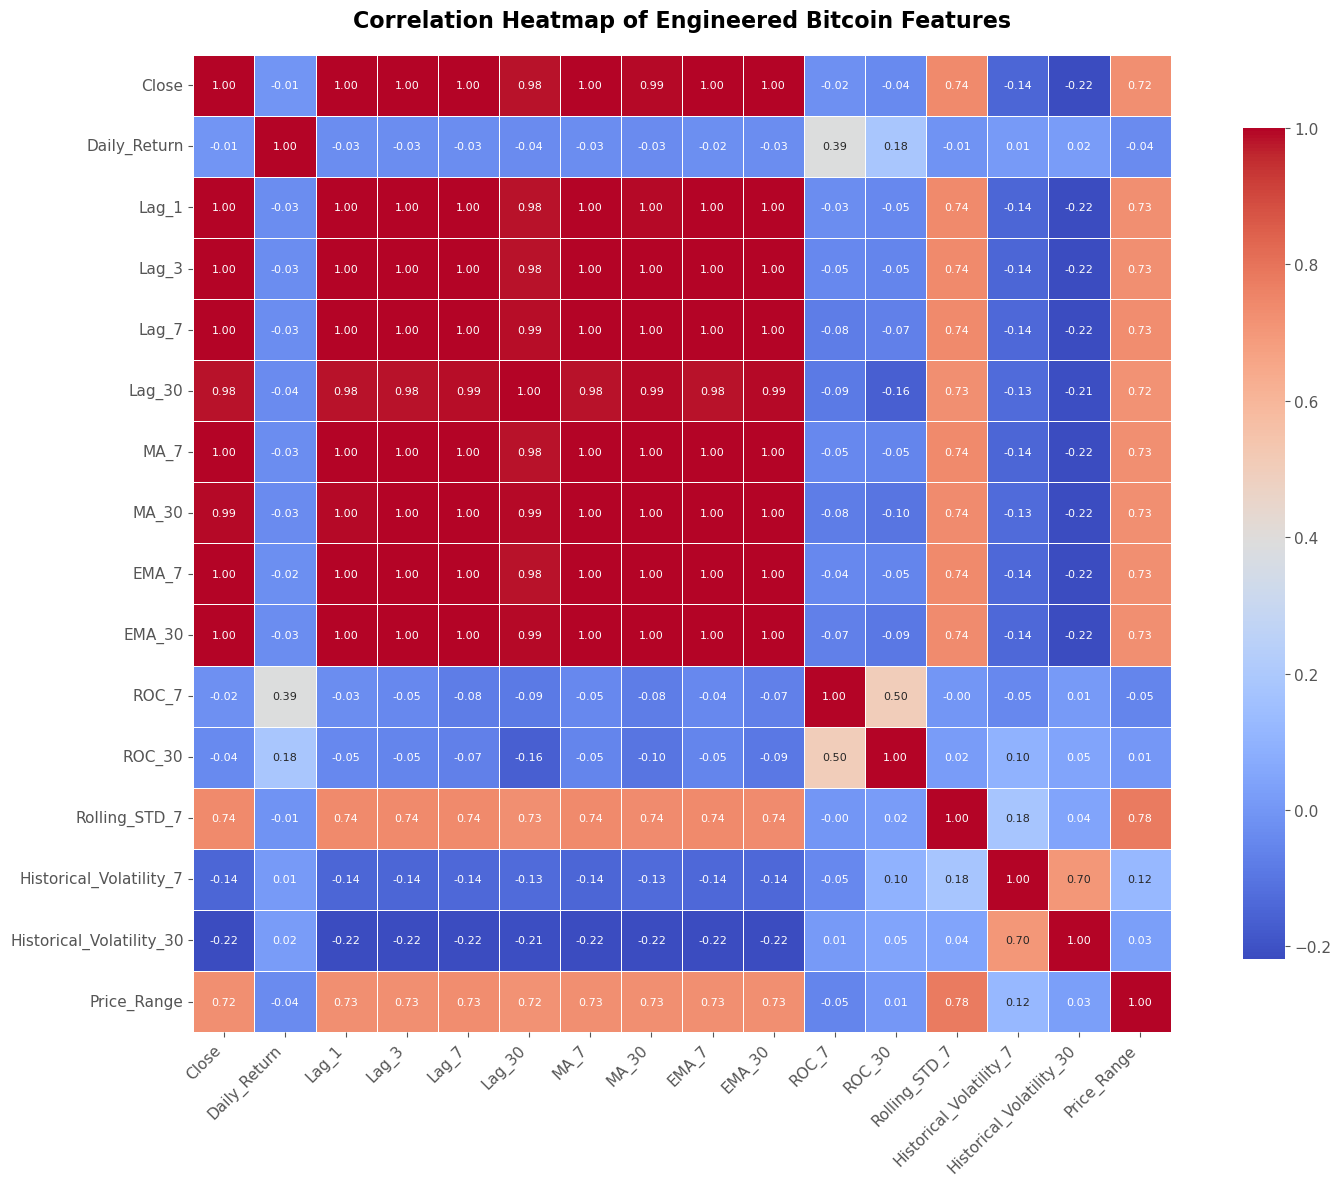

In [45]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.85}
)

plt.title(
    "Correlation Heatmap of Engineered Bitcoin Features",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Observation

- The closing price exhibits a very strong positive correlation with all lag features (Lag?, Lag?, Lag?, and Lag??), indicating that Bitcoin prices are highly dependent on previous observations.
- The Moving Average (MA? and MA??) and Exponential Moving Average (EMA? and EMA??) features are strongly correlated with the closing price because they are derived from historical closing prices.
- ROC features capture price momentum over different time horizons, while Historical Volatility and Price Range provide complementary information about market variability.


## Business Insight

The correlation analysis reveals that historical prices and trend-based indicators move closely together, reflecting the persistence of Bitcoin's price movements over time. In contrast, return-based measures such as Daily Return and Historical Volatility capture different aspects of market behaviour, providing complementary information for financial analysis and risk assessment.

## Machine Learning Insight

The correlation matrix highlights that several trend-based features are highly correlated because they are derived from the closing price. While this may introduce redundancy for some algorithms, it is generally acceptable for tree-based models such as Random Forest and XGBoost. Features with weaker correlations, such as Daily Return and Historical Volatility, contribute additional information that may improve the model's ability to capture different market patterns.

-----

# FEATURE DISTRIBUTION
Feature distribution describes how the values of a feature are spread across the dataset.

By visualizing distributions using histograms, we can understand:

- The range of values
- The concentration of observations
- The presence of skewness
- Potential outliers
- Overall data patterns

Understanding feature distributions is an important step before training machine learning models, as it helps identify whether transformations or scaling may be required.

## Importance of Feature Distribution

Distribution analysis helps us:

- Understand the behaviour of engineered features.
- Detect skewed or unusual value distributions.
- Identify possible outliers.
- Assess whether preprocessing techniques such as scaling or normalization may be beneficial.

## Visualizing Feature Distributions

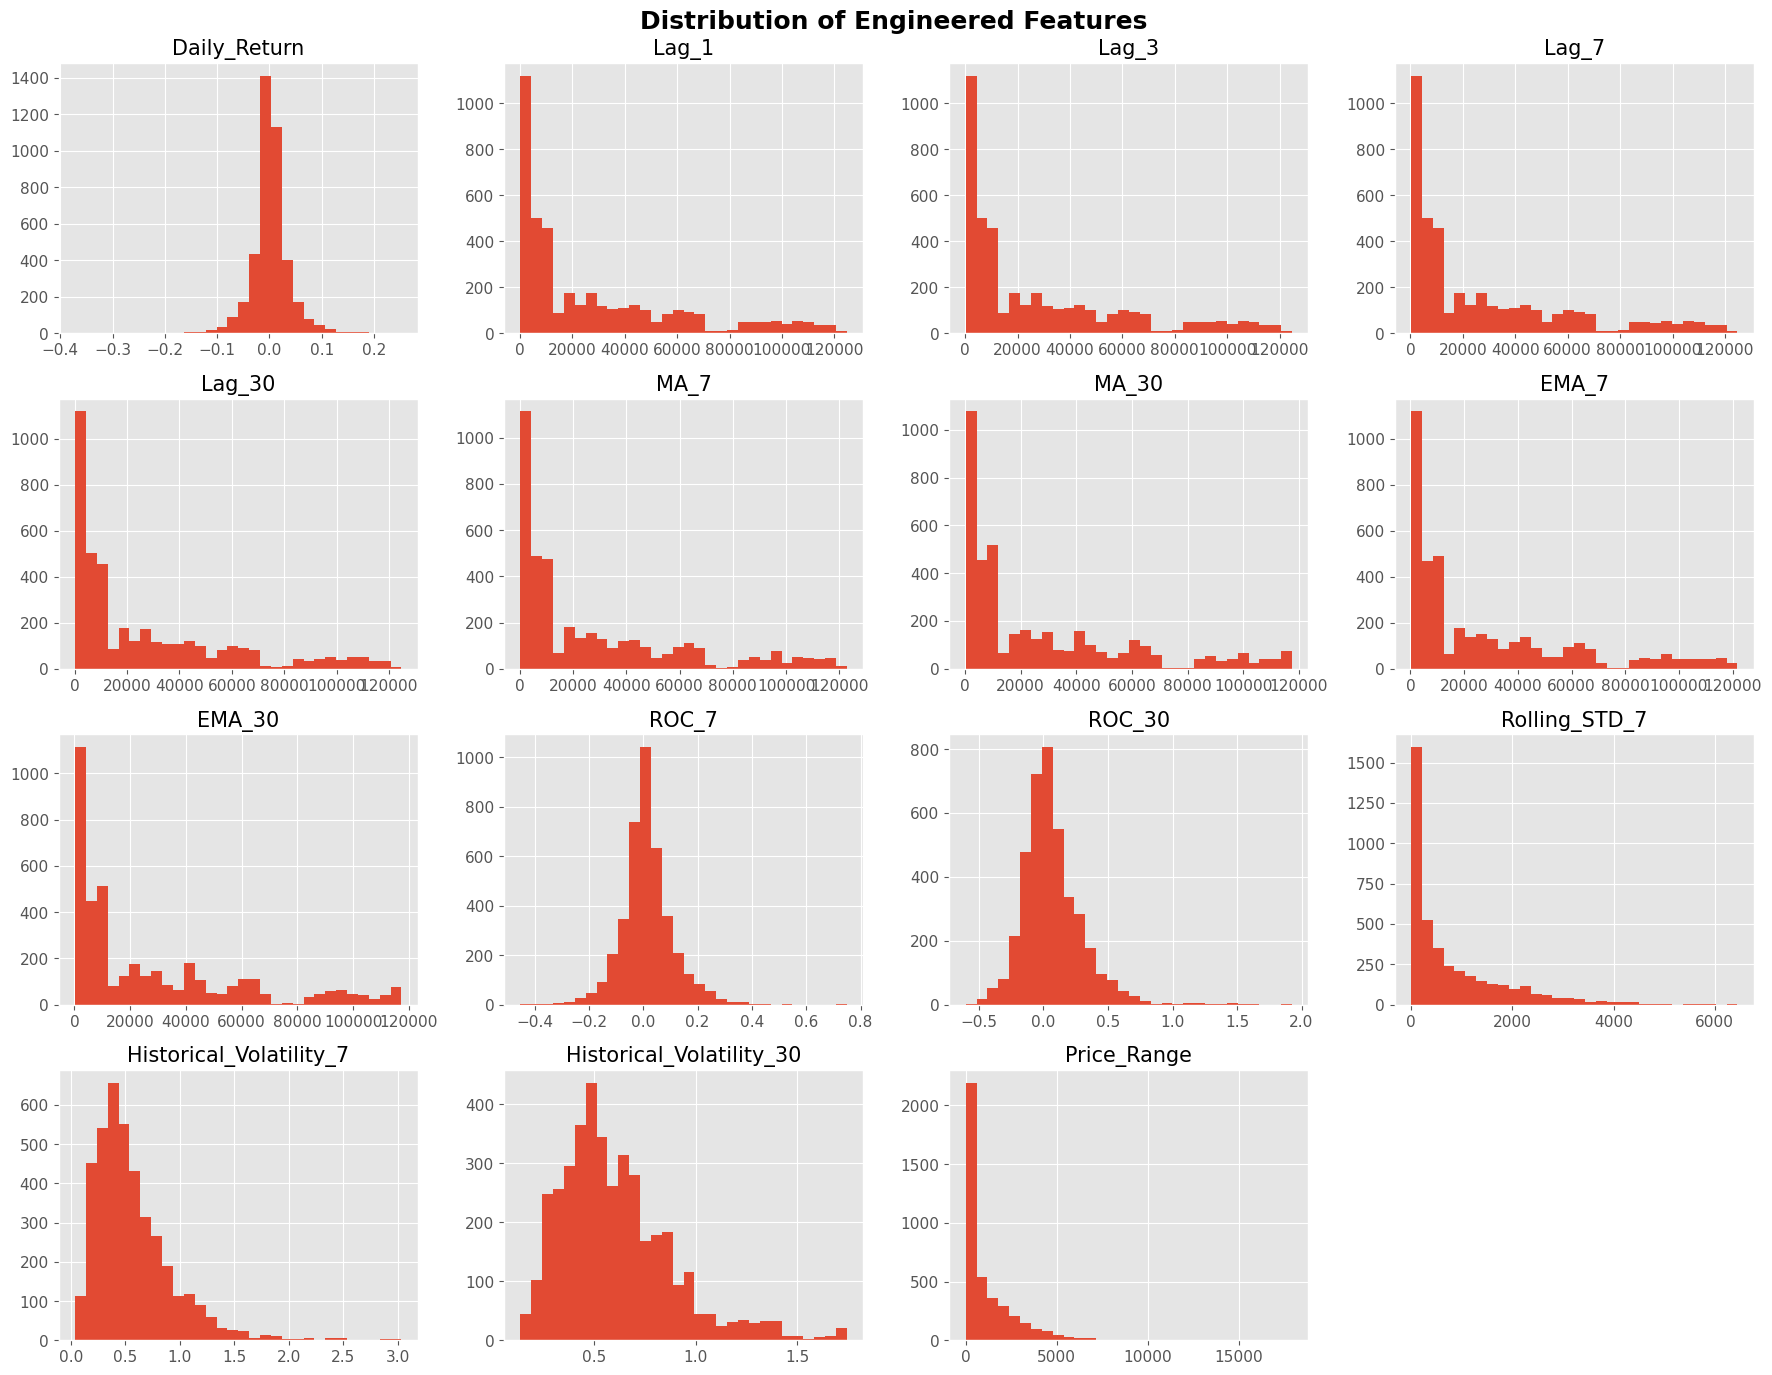

In [46]:
distribution_columns = [
    "Daily_Return",
    "Lag_1",
    "Lag_3",
    "Lag_7",
    "Lag_30",
    "MA_7",
    "MA_30",
    "EMA_7",
    "EMA_30",
    "ROC_7",
    "ROC_30",
    "Rolling_STD_7",
    "Historical_Volatility_7",
    "Historical_Volatility_30",
    "Price_Range"
]

df[distribution_columns].hist(
    figsize=(18, 14),
    bins=30
)

plt.suptitle(
    "Distribution of Engineered Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


## Observation

- Daily Return, ROC_7, and ROC_30 are centered around zero, indicating that small price changes are more common than large gains or losses.
- The lag, Moving Average, and Exponential Moving Average features display similar right-skewed distributions because they represent Bitcoin prices at different time horizons.
- Historical Volatility and Price Range features show that periods of elevated market risk and intraday movement occur less frequently than stable periods.


## Business Insight

The distributions confirm that extreme market events occur relatively infrequently, while moderate price movements and volatility levels represent normal Bitcoin market behaviour.


## Machine Learning Insight

Feature distributions provide valuable information about the characteristics of the engineered dataset before model training. Several features exhibit positive skewness, which is common in financial time-series data. Understanding these distributions helps determine whether preprocessing techniques such as scaling or transformation may improve model performance and stability.

# FEATURE ENGINEERING SUMMARY
The following table summarizes all the engineered features created throughout this notebook, along with their purpose and contribution to the machine learning pipeline.

In [47]:
feature_summary = pd.DataFrame({
    "Feature": [
        "Daily_Return", "Lag_1", "Lag_3", "Lag_7", "Lag_30",
        "MA_7", "MA_30", "EMA_7", "EMA_30", "ROC_7", "ROC_30",
        "Rolling_STD_7", "Historical_Volatility_7", "Historical_Volatility_30", "Price_Range"
    ],
    "Purpose": [
        "Daily percentage price change",
        "Previous day's closing price",
        "Closing price from 3 days ago",
        "Closing price from 7 days ago",
        "Closing price from 30 days ago",
        "7-day simple moving average",
        "30-day simple moving average",
        "7-day exponential moving average",
        "30-day exponential moving average",
        "7-day price momentum",
        "30-day price momentum",
        "7-day rolling price variability",
        "7-day annualized return volatility",
        "30-day annualized return volatility",
        "Daily high-low price difference"
    ]
})

feature_summary


,Feature,Purpose
0,Daily_Return,Daily percentage price change
1,Lag_1,Previous day's closing price
2,Lag_3,Closing price from 3 days ago
3,Lag_7,Closing price from 7 days ago
4,Lag_30,Closing price from 30 days ago
5,MA_7,7-day simple moving average
6,MA_30,30-day simple moving average
7,EMA_7,7-day exponential moving average
8,EMA_30,30-day exponential moving average
9,ROC_7,7-day price momentum


## Observation

A diverse set of engineered features has been created to capture different aspects of Bitcoin market behaviour.

- **Lag Features** preserve historical price information across multiple time horizons.
- **Trend Features** smooth price fluctuations and highlight long-term market direction.
- **Volatility Features** quantify market uncertainty and price variability.
- **Return Features** measure day-to-day percentage price changes.
- **Price Action Features** capture intraday market movement.

Together, these engineered features provide a comprehensive representation of Bitcoin's historical behaviour for machine learning models.

## Business Insight

The engineered dataset now captures trends, momentum, volatility, and intraday market behaviour — providing a comprehensive foundation for financial analysis and predictive decision-making.


## Machine Learning Insight

The engineered features provide richer information than the raw dataset alone, allowing predictive models to learn complex market patterns across multiple time horizons and improve forecasting performance.


# Save Final Engineered Dataset

The engineered dataset is now complete and ready for the next stage of the machine learning pipeline. Saving the dataset ensures that feature engineering does not need to be repeated during future experiments and provides a consistent input for feature selection and model development.


In [48]:
df_export = df.dropna().reset_index(drop=True)

print("Rows before dropping NaN :", len(df))
print("Rows after dropping NaN  :", len(df_export))
print("Rows removed             :", len(df) - len(df_export))

df_export.to_csv(
    "bitcoin_feature_engineered.csv",
    index=False
)

print("Feature engineered dataset saved successfully.")


Rows before dropping NaN : 4038
Rows after dropping NaN  : 4008
Rows removed             : 30
Feature engineered dataset saved successfully.


# CONCLUSION

In this notebook, the raw Bitcoin dataset was transformed into a feature-rich dataset through systematic feature engineering.

---

**Features Created**

A total of 15 engineered features were generated across four categories:

- **Trend Features** — Moving Averages and Exponential Moving Averages to capture short-term and long-term price direction.
- **Momentum Features** — Daily Return, Rate of Change, and Lag Features to represent price dynamics across multiple time horizons.
- **Volatility Features** — Rolling Standard Deviation and Historical Volatility to quantify market risk and uncertainty.
- **Price Action Features** — Price Range to capture intraday market movement.

**Dataset Prepared**

The final dataset has been validated, analysed for feature correlation and distribution, and saved as `bitcoin_feature_engineered.csv`. It is ready for model training in the subsequent notebooks.


In [49]:
print("=" * 60)
print("BitVision - Feature Engineering Summary")
print("=" * 60)
print(f"Original Columns : 6")
print(f"Engineered Features : 15")
print(f"Total Columns : {len(df_export.columns)}")
print(f"Total Records : {len(df_export):,}")
print("=" * 60)
print("Version 2 Completed Successfully")


BitVision - Feature Engineering Summary
Original Columns : 6
Engineered Features : 15
Total Columns : 21
Total Records : 4,008
Version 2 Completed Successfully
